ImportLibraries

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os
from PIL import Image
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split

In [ ]:
import zipfile
import os

# Step 1: Extract the zip
zip_path = "/content/Copy of devnagari digit.zip"
extract_path = "/content/"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction Done ✓")

# Step 2: See what folder was created
print(os.listdir("/content/"))

Extraction Done ✓
['.config', 'Copy of devnagari digit.zip', 'DevanagariHandwrittenDigitDataset', 'sample_data']


Load the Devnagari Dataset

In [ ]:
import os
from PIL import Image
import numpy as np

# Correct dataset path
dataset_path = "/content/DevanagariHandwrittenDigitDataset/Train"

IMG_SIZE = 32
images = []

for class_folder in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, class_folder)

    if os.path.isdir(class_path):
        for img_file in os.listdir(class_path):
            img_path = os.path.join(class_path, img_file)

            try:
                img = Image.open(img_path).convert('L')  # grayscale
                img = img.resize((IMG_SIZE, IMG_SIZE))
                images.append(np.array(img))

            except Exception as e:
                print(f"Skipped: {img_path} - {e}")

images = np.array(images)

print("✅ Total images loaded:", images.shape)

✅ Total images loaded: (17000, 32, 32)


 Normalize & Reshape

In [ ]:
# Normalize to [0, 1]
images = images.astype('float32') / 255.

# Reshape to add channel dimension → (N, 32, 32, 1)
images = np.reshape(images, (len(images), IMG_SIZE, IMG_SIZE, 1))

print(f"Images shape after reshape: {images.shape}")

Images shape after reshape: (17000, 32, 32, 1)


Split into Train and Validation Sets

In [ ]:
x_train, x_val = train_test_split(images, test_size=0.2, random_state=42)

print(f"Training set   : {x_train.shape}")
print(f"Validation set : {x_val.shape}")

Training set   : (13600, 32, 32, 1)
Validation set : (3400, 32, 32, 1)


Visualize Original vs Noisy Images

In [ ]:
import numpy as np

# Normalize images (important for noise addition)
x_train = x_train.astype('float32') / 255.0

# Add Gaussian noise
noise_factor = 0.5
x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_train.shape
)

# Clip values to keep them valid (0–1)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)

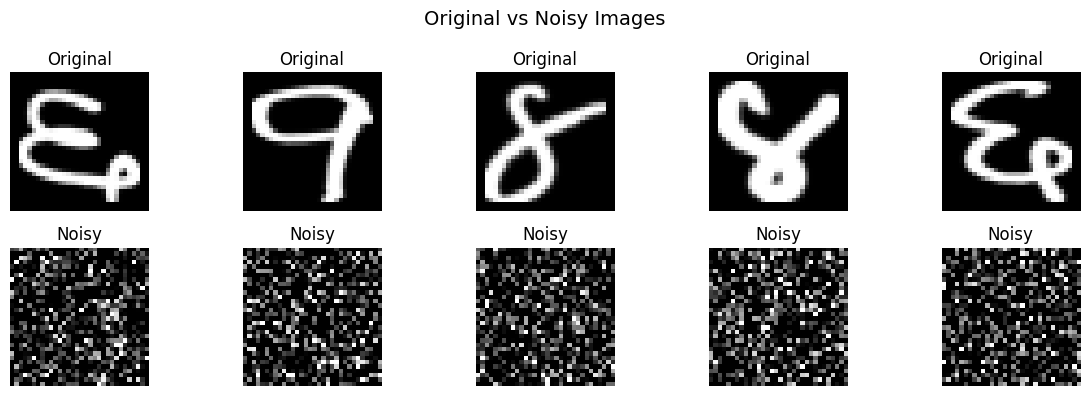

In [ ]:
import matplotlib.pyplot as plt

n = 5  # number of images to show

plt.figure(figsize=(12, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Noisy
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
    plt.title("Noisy")
    plt.axis('off')

plt.suptitle("Original vs Noisy Images", fontsize=14)
plt.tight_layout()
plt.show()

 Build the Encoder (4 layers deep)

In [ ]:
def build_encoder(input_shape=(32, 32, 1)):
    """
    Encoder: compresses input image into latent representation.
    4 Convolutional layers with MaxPooling for downsampling.
    """
    input_img = Input(shape=input_shape, name="encoder_input")

    # Layer 1
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 32x32 → 16x16

    # Layer 2
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 16x16 → 8x8

    # Layer 3
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = MaxPooling2D((2, 2), padding='same')(x)       # 8x8 → 4x4

    # Layer 4
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(x)
    encoded = MaxPooling2D((2, 2), padding='same', name="latent_space")(x)  # 4x4 → 2x2

    return input_img, encoded

print("Encoder built ✓")

Encoder built ✓


Build the Decoder (4 layers deep)

In [ ]:
def build_decoder(encoded_input):
    """
    Decoder: reconstructs image from latent representation.
    4 Convolutional layers with UpSampling for upsampling back to original size.
    """

    # Layer 1
    x = Conv2D(256, (3, 3), activation='relu', padding='same')(encoded_input)
    x = UpSampling2D((2, 2))(x)       # 2x2 → 4x4

    # Layer 2
    x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)       # 4x4 → 8x8

    # Layer 3
    x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)       # 8x8 → 16x16

    # Layer 4
    x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
    x = UpSampling2D((2, 2))(x)       # 16x16 → 32x32

    # Output layer — sigmoid keeps values in [0, 1]
    decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same', name="decoder_output")(x)

    return decoded

print("Decoder built ✓")

Decoder built ✓


Combine into Full Autoencoder

In [ ]:
def build_autoencoder(input_shape=(32, 32, 1)):
    """
    Combines encoder and decoder into one full autoencoder model.
    """
    input_img, encoded_output = build_encoder(input_shape)
    decoded_output = build_decoder(encoded_output)

    autoencoder = Model(inputs=input_img, outputs=decoded_output, name="denoising_autoencoder")
    return autoencoder

autoencoder = build_autoencoder()
print("Full Autoencoder built ✓")

Full Autoencoder built ✓


Compile the Model

In [ ]:
autoencoder.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy'
)

autoencoder.summary()

Model: "denoising_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ encoder_input (InputLayer)      │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 32, 32, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 4, 4, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 4, 4, 256)      │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (MaxPooling2D)     │ (None, 2, 2, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 2, 2, 256)      │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 4, 4, 256)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 4, 4, 128)      │       295,040 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 8, 8, 64)       │        73,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_2 (UpSampling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 16, 16, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_3 (UpSampling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ decoder_output (Conv2D)         │ (None, 32, 32, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,365,505 (5.21 MB)

 Trainable params: 1,365,505 (5.21 MB)

 Non-trainable params: 0 (0.00 B)

Train the Autoencoder

In [ ]:
import numpy as np

# Normalize validation set (if not already done)
x_val = x_val.astype('float32') / 255.0

# Add noise to validation data
noise_factor = 0.5
x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0, scale=1.0, size=x_val.shape
)

# Clip values to [0,1]
x_val_noisy = np.clip(x_val_noisy, 0., 1.)

In [ ]:
EPOCHS = 20
BATCH_SIZE = 64

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

print("Training Complete ✓")

Epoch 1/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 149s 678ms/step - loss: 0.0182 - val_loss: 0.0073
Epoch 2/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 181s 581ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 3/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 583ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 4/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 130s 611ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 5/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 139s 596ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 6/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 140s 585ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 7/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 144s 597ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 8/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 140s 589ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 9/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 144s 597ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 10/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 142s 599ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 11/20
213/213 ━━━━━━━━━━━━━━━━━━━━ 141s 593ms/step - loss: 0.0073 - val_loss: 0.0073
Epoch 12

Plot Training & Validation Loss

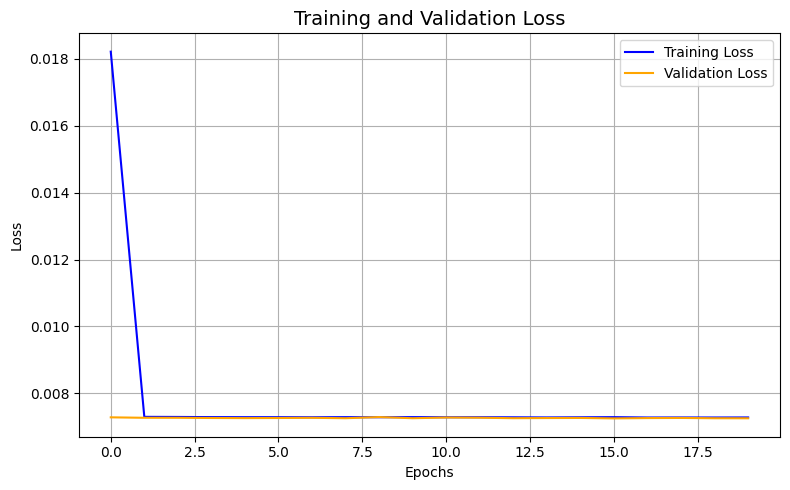

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'],     label='Training Loss',   color='blue')
plt.plot(history.history['val_loss'], label='Validation Loss', color='orange')
plt.title('Training and Validation Loss', fontsize=14)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

Predict Denoised Images

In [ ]:
denoised_images = autoencoder.predict(x_val_noisy)
print(f"Denoised images shape: {denoised_images.shape}")

107/107 ━━━━━━━━━━━━━━━━━━━━ 7s 64ms/step
Denoised images shape: (3400, 32, 32, 1)


Visualize Noisy vs Denoised vs Clean

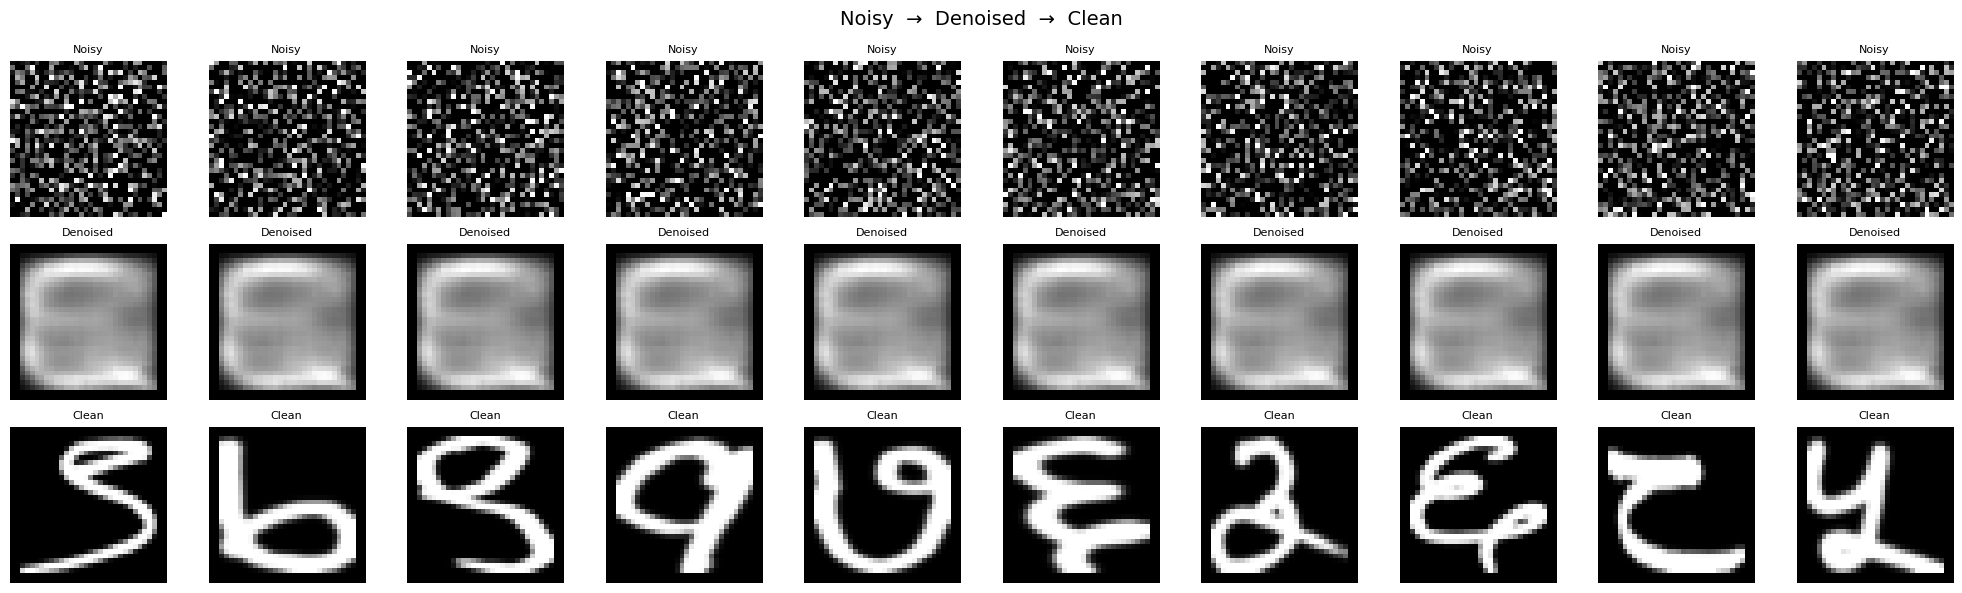

In [ ]:
def plot_results(noisy, denoised, clean, n=10, img_size=32):
    plt.figure(figsize=(20, 6))

    for i in range(n):
        # Row 1: Noisy
        plt.subplot(3, n, i + 1)
        plt.imshow(noisy[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Noisy", fontsize=8)
        plt.axis('off')

        # Row 2: Denoised
        plt.subplot(3, n, i + 1 + n)
        plt.imshow(denoised[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Denoised", fontsize=8)
        plt.axis('off')

        # Row 3: Clean
        plt.subplot(3, n, i + 1 + 2 * n)
        plt.imshow(clean[i].reshape(img_size, img_size), cmap='gray')
        plt.title("Clean", fontsize=8)
        plt.axis('off')

    plt.suptitle("Noisy  →  Denoised  →  Clean", fontsize=14)
    plt.tight_layout()
    plt.show()

plot_results(x_val_noisy, denoised_images, x_val, n=10)

Save the Model

In [ ]:
autoencoder.save("devnagari_denoising_autoencoder.keras")
print("Model saved ✓")

Model saved ✓


Experiment: Try Different Noise Levels


Noise Factor: 0.1


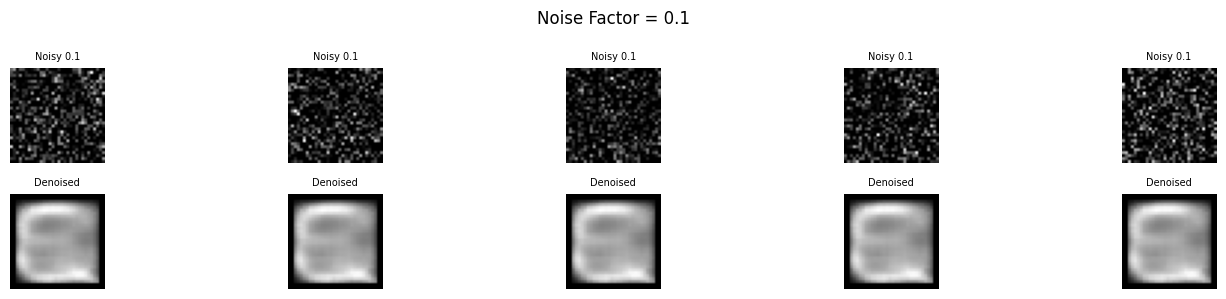


Noise Factor: 0.3


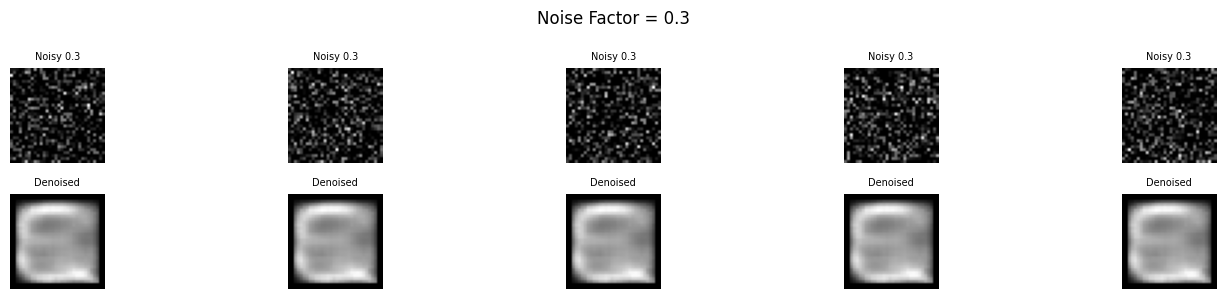


Noise Factor: 0.5


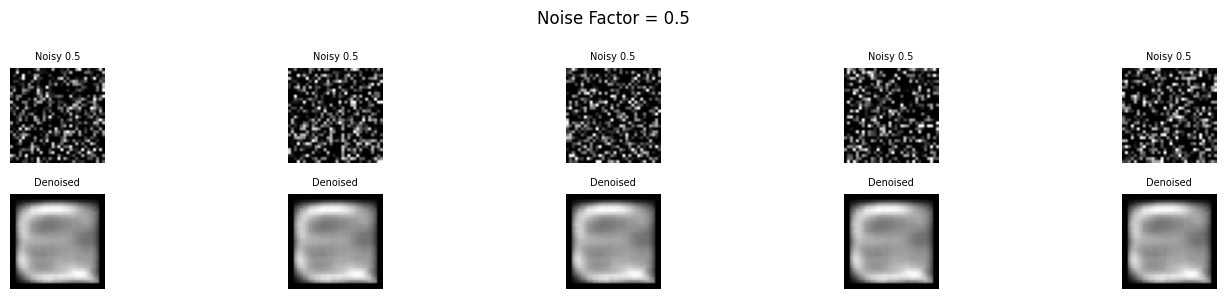


Noise Factor: 0.7


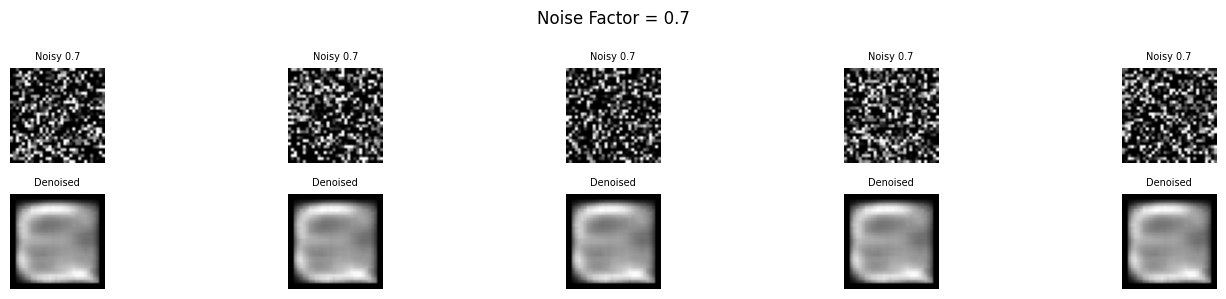

In [ ]:
for noise_level in [0.1, 0.3, 0.5, 0.7]:
    x_test_exp = x_val + noise_level * np.random.normal(size=x_val.shape)
    x_test_exp = np.clip(x_test_exp, 0., 1.)

    denoised_exp = autoencoder.predict(x_test_exp, verbose=0)

    print(f"\nNoise Factor: {noise_level}")
    plt.figure(figsize=(15, 3))
    for i in range(5):
        plt.subplot(2, 5, i + 1)
        plt.imshow(x_test_exp[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title(f"Noisy {noise_level}", fontsize=7)
        plt.axis('off')

        plt.subplot(2, 5, i + 6)
        plt.imshow(denoised_exp[i].reshape(IMG_SIZE, IMG_SIZE), cmap='gray')
        plt.title("Denoised", fontsize=7)
        plt.axis('off')

    plt.suptitle(f"Noise Factor = {noise_level}", fontsize=12)
    plt.tight_layout()
    plt.show()